# **Setup & Data Loading**

In [14]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import joblib
import torch
from sklearn.metrics import classification_report, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# **Peformance Evaluation**

## **Classification Report**

In [3]:
# Load test set
test_df = pd.read_csv("../data/splits/test.csv")

# ── TF-IDF ──────────────────────────────────────
pipeline = joblib.load("../models/baseline/tfidf_pipeline.joblib")
tfidf_preds = pipeline.predict(test_df["text"])

print("=== TF-IDF + Logistic Regression ===")
print(classification_report(test_df["label"], tfidf_preds,
                            target_names=["Non-ADE", "ADE"]))

# ── BioBERT ──────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained("../models/biobert_finetuned")
model = AutoModelForSequenceClassification.from_pretrained("../models/biobert_finetuned")
model = model.to("cuda")
model.eval()

all_preds = []
batch_size = 32

with torch.no_grad():
    for i in range(0, len(test_df), batch_size):
        batch = test_df["text"][i:i+batch_size].tolist()
        inputs = tokenizer(batch, padding=True, truncation=True,
                          max_length=128, return_tensors="pt").to("cuda")
        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)

print("=== BioBERT ===")
print(classification_report(test_df["label"], all_preds,
                            target_names=["Non-ADE", "ADE"]))

=== TF-IDF + Logistic Regression ===
              precision    recall  f1-score   support

     Non-ADE       0.95      0.91      0.93      2505
         ADE       0.80      0.88      0.84      1023

    accuracy                           0.90      3528
   macro avg       0.87      0.89      0.88      3528
weighted avg       0.91      0.90      0.90      3528

=== BioBERT ===
              precision    recall  f1-score   support

     Non-ADE       0.98      0.96      0.97      2505
         ADE       0.91      0.95      0.93      1023

    accuracy                           0.96      3528
   macro avg       0.95      0.96      0.95      3528
weighted avg       0.96      0.96      0.96      3528



## **Confusion Matricies**

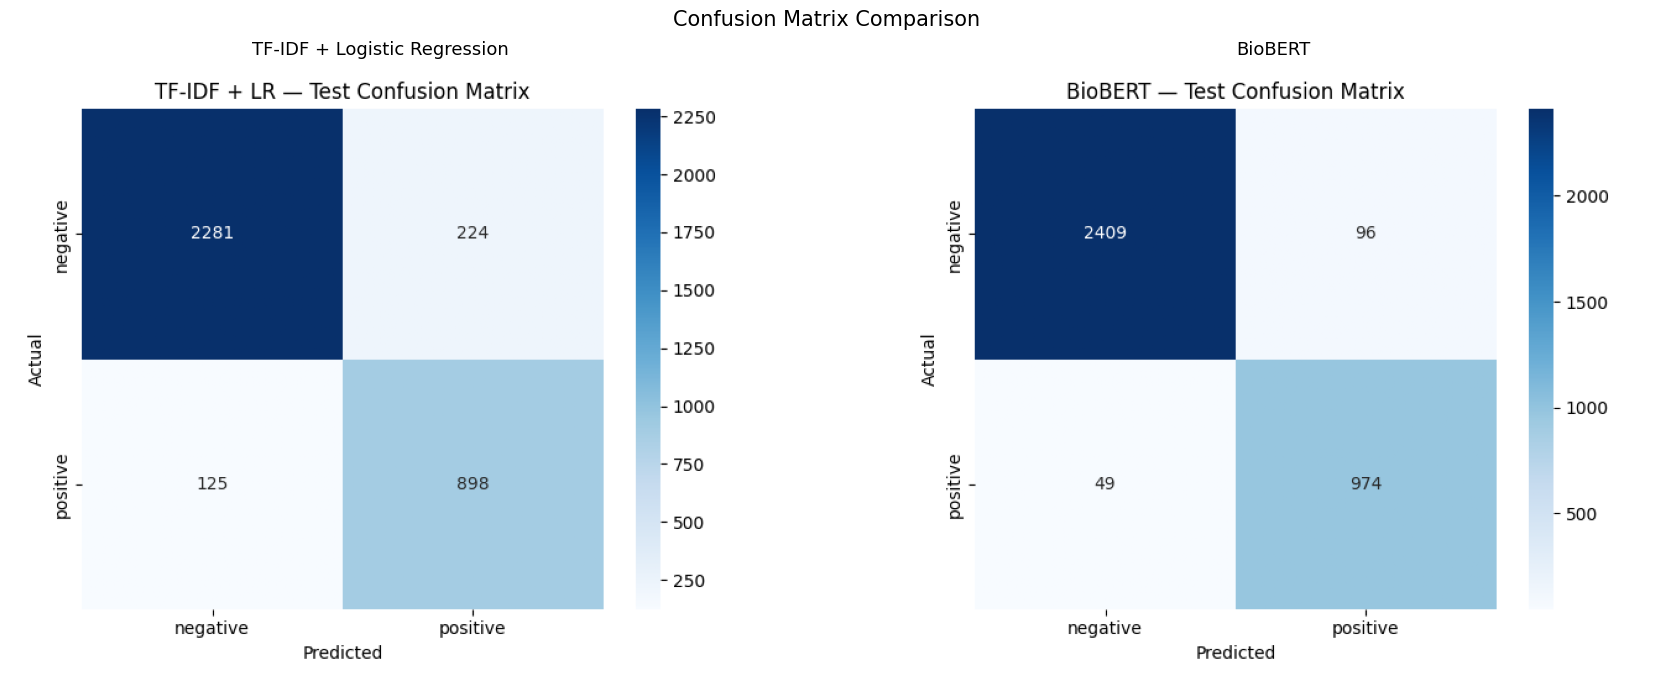

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(mpimg.imread('../reports/figures/baseline_cm.png'))
axes[0].axis('off')
axes[0].set_title('TF-IDF + Logistic Regression', fontsize=13)

axes[1].imshow(mpimg.imread('../reports/figures/biobert_cm.png'))
axes[1].axis('off')
axes[1].set_title('BioBERT', fontsize=13)

plt.suptitle('Confusion Matrix Comparison', fontsize=15)
plt.tight_layout()
plt.show()

# **Visualizing Model Errors**

In [5]:
baseline_errors = pd.read_csv("../reports/results/baseline_errors.csv")
biobert_errors  = pd.read_csv("../reports/results/biobert_errors.csv")

tfidf_only = baseline_errors[
    ~baseline_errors["text"].isin(biobert_errors["text"])
]
  
biobert_only = biobert_errors[
    ~biobert_errors["text"].isin(baseline_errors["text"])
]

both_wrong = baseline_errors[
    baseline_errors["text"].isin(biobert_errors["text"])
]

print(f"TF-IDF wrong, BioBERT right: {len(tfidf_only)}")
print(f"BioBERT wrong, TF-IDF right: {len(biobert_only)}")
print(f"Both wrong:                  {len(both_wrong)}")

TF-IDF wrong, BioBERT right: 276
BioBERT wrong, TF-IDF right: 72
Both wrong:                  73


## **Case 1: TF-IDF wrong, BioBERT right** 

In [6]:
for i, row in tfidf_only.head(15).iterrows():
    print(f"True: {row['true']} | Pred: {row['predicted']}")
    print(f"  {row['text'][:120]}")
    print()

True: negative | Pred: positive
  Shortly after hepatic artery clamping the patient developed a massive intracardiac/intravascular thrombosis that resulte

True: positive | Pred: negative
  Ampicillin may aggravate clinical and experimental myasthenia gravis.

True: negative | Pred: positive
  A fifth child manifested clinical and radiographic signs of rickets after presenting with hypophosphatemia, hypouricemia

True: negative | Pred: positive
  Further research into the mechanism of IFN related cutaneous side effects is needed.

True: negative | Pred: positive
  Specific antiinfectious therapy together with cyclosporine and dexamethasone may be a therapeutic approach.

True: negative | Pred: positive
  PURPOSE: To evaluate the toxicity of 1 mg of intraocular rituximab and to present a small case-series of patients treate

True: positive | Pred: negative
  Detection of activated eosinophils in nasal polyps of an aspirin-induced asthma patient.

True: positive | Pred: negative
  The as

## **Case 2: BioBERT wrong, TF-IDF right**

In [29]:
for i, row in biobert_only.head(15).iterrows():
    print(f"True: {row['true']} | Pred: {row['predicted']}")
    print(f"  {row['text'][:120]}")
    print()

True: negative | Pred: positive
  We report a case of CMV ventriculoencephalitis after unrelated double cord blood SCT with an alemtuzumab-containing prep

True: negative | Pred: positive
  Cisplatin toxicity on cardiac electrical activity is discussed.

True: positive | Pred: negative
  Treatment of ELP in children is generally supportive, with the symptoms and roentgenographic abnormalities resolving wit

True: negative | Pred: positive
  (2) In 8 out of 13 cases without recombinant human EPO treatment before PTX, a 10% increase in RBC was observed after PT

True: negative | Pred: positive
  OBJECTIVE: To report a case of spontaneous hemothorax following anticoagulation with low-molecular-weight heparin (LMWH)

True: negative | Pred: positive
  A causal relationship of phrenal neuropathy with adalimumab is herein discussed.

True: negative | Pred: positive
  Awareness of the various potential gastrointestinal toxic effects of bortezomib is of relevance given the growing number

True:

## **Case 3: Both Wrong**

In [28]:
for i, row in both_wrong.head(15).iterrows():
    print(f"True: {row['true']} | Pred: {row['predicted']}")
    print(f"  {row['text'][:120]}")
    print()

True: negative | Pred: positive
  In the Perugia Consensus Conference it was decided that the recommended antiemetic regimen in the prevention of acute em

True: positive | Pred: negative
  CONCLUSIONS: Spontaneous hemothorax is a rare phenomenon in conjunction with LMWH but should be considered in cases of a

True: negative | Pred: positive
  Marginal crack after intravitreal bevacizumab for myopic choroidal neovascularization.

True: negative | Pred: positive
  Gastric-outlet obstruction induced by prostaglandin therapy in neonates.

True: negative | Pred: positive
  We describe three blood brothers who were involved in pottery glazing and suffered from repeated episodes of severe abdo

True: positive | Pred: negative
  She continued taking verapamil for 6 months, then, on her own, stopped all medications including the sustained-release v

True: negative | Pred: positive
  We report the occurrence of a cerebral hemorrhage related to cerebral amyloid angiopathy in a patient who underw

## **Error Analysis Summary**

Of the 349 TF-IDF errors and 145 BioBERT errors on the test set, 276 sentences 
were misclassified by TF-IDF alone, 72 by BioBERT alone, and 73 by both models.
TF-IDF failures concentrate on sentences where adverse effect vocabulary appears 
without actual causation including meta-sentences discussing toxicity, hedged language 
using "may" or "discussed", and negated statements. These cases require 
understanding sentence context which sparse word frequency representations 
fundamentally cannot capture. BioBERT failures concentrate on sentences where strong biomedical signal exists without a true adverse event. As such pharmacological events can be labeled as adverse effects without actual confirmation. The 73 sentences both models failed on represent the genuine 
ceiling of sentence-level classification on this corpus, where causation can be
implied across sentences rather than stated explicitly within one.

# **Model Interpretability**

## **TF-IDF Logistic Regression Token Weights**
The TF-IDF weight inspection reveals the classical model learned meaningful linguistic signals. Causal verbs such as "induced", "developed", and "following" correctly received the highest positive weights, consistent with the ADE annotation requirement for explicit drug-adverse effect causation. However the non-ADE predictors reveal a key limitation. The bigram "drug induced" received the strongest negative weight despite being semantically associated with adverse effects, reflecting a corpus artifact where the phrase appears predominantly in meta-sentences discussing drug-induced conditions generally rather than describing a specific adverse event. TF-IDF cannot distinguish between these contexts, which is precisely the type of disambiguation that BioBERT's attention mechanism handles through sentence-level contextual understanding.

In [25]:
pipeline = joblib.load("../models/baseline/tfidf_pipeline.joblib")
vectorizer = pipeline.named_steps["tfidf"]
classifier = pipeline.named_steps["clf"]

feature_names = vectorizer.get_feature_names_out()
weights = classifier.coef_[0]

top_positive = sorted(zip(weights, feature_names), reverse=True)[:20]
top_negative = sorted(zip(weights, feature_names))[:20]

print("Strongest ADE predictors (label 1):")
for w, f in top_positive:
    print(f"  {f:35s}  {w:+.3f}")

print("\nStrongest Non-ADE predictors (label 0):")
for w, f in top_negative:
    print(f"  {f:35s}  {w:+.3f}")

Strongest ADE predictors (label 1):
  induced                              +16.820
  associated                           +11.221
  after                                +9.117
  neurotoxicity                        +8.687
  toxicity                             +7.683
  developed                            +7.664
  tamoxifen                            +7.177
  ibuprofen                            +7.126
  mtx                                  +7.084
  following                            +7.045
  gold                                 +7.027
  during                               +7.013
  risperidone                          +6.582
  theophylline                         +6.520
  methotrexate                         +6.442
  hepatotoxicity                       +6.337
  taking                               +6.334
  cyclosporine                         +6.315
  hypersensitivity                     +6.296
  ifosfamide                           +6.288

Strongest Non-ADE predictors (label 0):
 

## **BioBERT Fine - Tuning Training Curve**
BioBERT reached 94.3% validation F1 after a single epoch, reflecting the 
strong biomedical language understanding inherited from PubMed pretraining. 
Performance improved marginally through epoch 2 then plateaued while 
validation loss continued rising, indicating the model had converged and 
additional training would risk overfitting. The best checkpoint was 
correctly selected at epoch 3 by F1 score.

In [26]:
with open("../models/biobert_finetuned/checkpoint-3087/trainer_state.json") as f:
    state = json.load(f)

epochs, val_f1, val_loss = [], [], []
for entry in state["log_history"]:
    if "eval_f1" in entry:
        epochs.append(int(entry["epoch"]))
        val_f1.append(entry["eval_f1"])
        val_loss.append(entry["eval_loss"])

print("Logged eval entries:")
for e, f, l in zip(epochs, val_f1, val_loss):
    print(f"  Epoch {e}  Val F1: {f:.4f}  Val Loss: {l:.4f}")

Logged eval entries:
  Epoch 1  Val F1: 0.9432  Val Loss: 0.1892
  Epoch 2  Val F1: 0.9523  Val Loss: 0.1972
  Epoch 3  Val F1: 0.9524  Val Loss: 0.2374


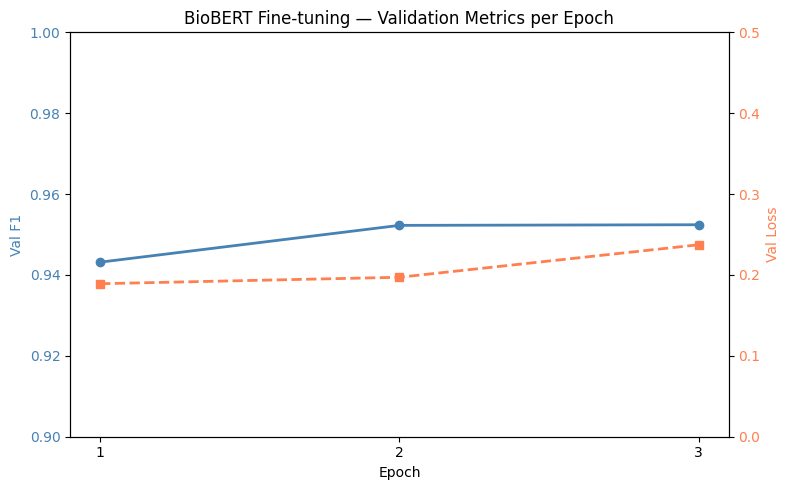

In [27]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Val F1", color="steelblue")
ax1.plot(epochs, val_f1, color="steelblue", marker="o", linewidth=2, label="Val F1")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticks([1, 2, 3])

ax2 = ax1.twinx()
ax2.set_ylabel("Val Loss", color="coral")
ax2.plot(epochs, val_loss, color="coral", marker="s", linewidth=2, 
         linestyle="--", label="Val Loss")
ax2.tick_params(axis="y", labelcolor="coral")

ax1.set_ylim(0.90, 1.0)
ax2.set_ylim(0.0, 0.5)

plt.title("BioBERT Fine-tuning — Validation Metrics per Epoch")
fig.tight_layout()
plt.savefig("../reports/figures/training_curve.png", dpi=150)
plt.show()